# PyTorch Autograd - Automatic Differentiation

A complete guide to understanding and using PyTorch's automatic differentiation system.

---

## Table of Contents

1. [What is Autograd?](#what-is-autograd)
2. [Why Do We Need Gradients?](#why-gradients)
3. [Basic Concepts](#basic-concepts)
4. [Simple Examples](#simple-examples)
5. [Computation Graph](#computation-graph)
6. [Gradient Methods](#gradient-methods)
---

In [106]:
# Setup
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} ")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory/1e9: 0.2} GB")

PyTorch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU 
Memory:  8.3 GB


---

# PART 1: Understanding Autograd

---

<a id='what-is-autograd'></a>
## What is Autograd?

**Autograd** (Automatic Differentiation) is PyTorch's system for automatically computing gradients (derivatives).

### Key Points:
- Automatically calculates derivatives using the **chain rule**
- Essential for training neural networks via **backpropagation**
- Builds a **dynamic computation graph** as operations are performed
- No need to manually compute gradients! 🎉

<a id='why-gradients'></a>
## Why Do We Need Gradients?

In machine learning, we need to:

1. **Forward Pass**: Make predictions → Calculate loss
2. **Backward Pass**: Calculate gradients (how to change weights)
3. **Update**: Adjust weights to reduce loss

```
Input → Model → Prediction → Loss
                                ↓
Update ← Gradients ← Backward Pass
```

Autograd handles step 2 automatically!

---

# PART 2: Basic Concepts

---

<a id='basic-concepts'></a>
## The Core Components

### 1. `requires_grad=True`
Tells PyTorch to track operations on this tensor for gradient computation.

### 2. `.backward()`
Computes gradients (runs backpropagation).

### 3. `.grad`
Stores the computed gradient.

### 4. `grad_fn`
Tracks what function created this tensor (part of computation graph).

In [107]:
# 1. requires_grad=True - Enable gradient tracking
#creating a tensor using pytorch
x = torch.tensor([2.0, 3.0], requires_grad=True)
print(f"x: {x}")
print(f"x.requires_grad: {x.requires_grad}")
print(f"dimension of tensor: {x.ndim}")

# Forward computation
y = x ** 2
print(f"\ny: {y}")
z = y.sum()
print(f"z: {z}")

# 4. grad_fn - Shows what created this tensor
print(f"\ny.grad_fn: {y.grad_fn}")  # PowBackward x**2
print(f"z.grad_fn: {z.grad_fn}")    # SumBackward z = y.sum()

# 2. .backward() - Compute gradients
z.backward()

# 3. .grad - Access gradients
print(f"\nx.grad: {x.grad}")  # dz/dx = 2*x = [4, 6]
print(f"Expected: {2*x.data}")


print(f"\nusing fucntion: ")
def dy_dx(x):
    return 2*x
#calling fucntion
dy_dx(x)

x: tensor([2., 3.], requires_grad=True)
x.requires_grad: True
dimension of tensor: 1

y: tensor([4., 9.], grad_fn=<PowBackward0>)
z: 13.0

y.grad_fn: <PowBackward0 object at 0x75161ceaa230>
z.grad_fn: <SumBackward0 object at 0x75161cee5750>

x.grad: tensor([4., 6.])
Expected: tensor([4., 6.])

using fucntion: 


tensor([4., 6.], grad_fn=<MulBackward0>)

---

# PART 3: Simple Examples

---

<a id='simple-examples'></a>
## Example 1: Simple Derivative

Calculate: $\frac{d}{dx}(x^2)$ at $x = 3$

Mathematical answer: $2x = 6$

In [108]:
# Create tensor with gradient tracking
x = torch.tensor([3.0], requires_grad=True)

# Forward pass
y = x ** 2

print(f"x = {x.item()}") #x = 3
print(f"y = x² = {y.item()}") #y = 9

# Backward pass
y.backward() 
print(x.grad)
print(x.grad_fn)

# Check gradient
print(f"\ndy/dx = {x.grad.item()}")
print(f"Expected (2x) = {2 * x.item()}")

def dy_dx(x):
    return 2*x
dy_dx(3)

x = 3.0
y = x² = 9.0
tensor([6.])
None

dy/dx = 6.0
Expected (2x) = 6.0


6

## Example 2: Multiple Operations

Calculate: $\frac{d}{dx}(3x^2 + 5)$ at $x = 2$

Mathematical answer: $6x = 12$

In [109]:
x = torch.tensor([2.0], requires_grad=True)

# Forward: y = 3x² + 5
y = 3 * x ** 2 + 5  # dy_dx = 6x

print(f"x = {x.item()}")
print(f"y = 3x² + 5 = {y.item()}")

# Backward
y.backward()

print(f"\ndy/dx = {x.grad.item()}")
print(f"Expected (6x) = {6 * x.item()}")

def dy_dx(x):
    return 6*x
dy_dx(x)

x = 2.0
y = 3x² + 5 = 17.0

dy/dx = 12.0
Expected (6x) = 12.0


tensor([12.], grad_fn=<MulBackward0>)

## Example 3: Multiple Inputs

Calculate gradients for: $z = a \times b$

In [110]:
a = torch.tensor([2.0], requires_grad=True)
b = torch.tensor([3.0], requires_grad=True)

# Forward
c = a * b

print(f"a = {a.item()}, b = {b.item()}")
print(f"c = a × b = {c.item()}")

# Backward
c.backward()

print(f"\ndc/da = {a.grad.item()} (Expected: b = {b.item()})")
print(f"dc/db = {b.grad.item()} (Expected: a = {a.item()})")

def dc_da(b):
    return b
dc_da(b)

a = 2.0, b = 3.0
c = a × b = 6.0

dc/da = 3.0 (Expected: b = 3.0)
dc/db = 2.0 (Expected: a = 2.0)


tensor([3.], requires_grad=True)

## Example 4: Vector Gradients

Compute gradients for vector inputs

In [111]:
# Vector input
x = torch.tensor([1.0, 2.0, 3.0, 4.0], requires_grad=True)

# Forward
y = x ** 2
z = y.sum()  # Need scalar for backward()

print(f"x: {x}")
print(f"y = x²: {y}")
print(f"z = sum(y): {z}")

# Backward
z.backward()

print(f"\ndz/dx: {x.grad}")
print(f"Expected (2x): {2*x.data}")

x: tensor([1., 2., 3., 4.], requires_grad=True)
y = x²: tensor([ 1.,  4.,  9., 16.], grad_fn=<PowBackward0>)
z = sum(y): 30.0

dz/dx: tensor([2., 4., 6., 8.])
Expected (2x): tensor([2., 4., 6., 8.])


---

# PART 4: Computation Graph

---

<a id='computation-graph'></a>
## Understanding the Computation Graph

PyTorch builds a **dynamic computation graph** that tracks all operations.

```
x (requires_grad=True)
  ↓
[**2] PowBackward
  ↓
  y
  ↓
[*3] MulBackward
  ↓
  z
  ↓
[+5] AddBackward
  ↓
  w
```

During `.backward()`, PyTorch traverses this graph **backwards** to compute gradients.

In [112]:
# Build a computation graph
x = torch.tensor([2.0], requires_grad=True)

y = x ** 2      # PowBackward
z = y * 3       # MulBackward
w = z + 5       # AddBackward

print("Computation Graph:")
print(f"x.grad_fn: {x.grad_fn}")  # None (leaf node)
print(f"y.grad_fn: {y.grad_fn}")  # PowBackward
print(f"z.grad_fn: {z.grad_fn}")  # MulBackward
print(f"w.grad_fn: {w.grad_fn}")  # AddBackward

# Backward
w.backward()

print(f"\ndw/dx = {x.grad}")
print(f"Expected (3 * 2x) = {3 * 2 * x.data}")

Computation Graph:
x.grad_fn: None
y.grad_fn: <PowBackward0 object at 0x75161cf22b90>
z.grad_fn: <MulBackward0 object at 0x75161cf23160>
w.grad_fn: <AddBackward0 object at 0x75161cf22b90>

dw/dx = tensor([12.])
Expected (3 * 2x) = tensor([12.])


## Leaf Tensors vs Non-Leaf Tensors

- **Leaf tensors**: Created by user (e.g., `torch.tensor([1.0], requires_grad=True)`)
- **Non-leaf tensors**: Created by operations on other tensors

Only **leaf tensors** store gradients in `.grad`

In [113]:
x = torch.tensor([2.0], requires_grad=True)  # Leaf
y = x ** 2                                    # Non-leaf
z = y + 3                                     # Non-leaf

print(f"x.is_leaf: {x.is_leaf}")  # True
print(f"y.is_leaf: {y.is_leaf}")  # False
print(f"z.is_leaf: {z.is_leaf}")  # False

z.backward()

print(f"\nx.grad: {x.grad}")      # Stored
print(f"y.grad: {y.grad}")        # None (non-leaf)
print(f"z.grad: {z.grad}")        # None (non-leaf)

x.is_leaf: True
y.is_leaf: False
z.is_leaf: False

x.grad: tensor([4.])
y.grad: None
z.grad: None


/tmp/ipykernel_14309/2875528154.py:12: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at aten/src/ATen/core/TensorBody.h:489.)
  print(f"y.grad: {y.grad}")        # None (non-leaf)
/tmp/ipykernel_14309/2875528154.py:13: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See gith

---

# PART 5: Gradient Methods

---

<a id='gradient-methods'></a>
## Method 1: `zero_grad()` - Clear Gradients

Gradients **accumulate** by default! Always clear them between iterations.

In [114]:
x = torch.tensor([2.0], requires_grad=True)

# First backward
y = x ** 2
y.backward()
print(f"After 1st backward: x.grad = {x.grad}")  # 4.0

# Second backward WITHOUT clearing
y = x ** 2
y.backward()
print(f"After 2nd backward: x.grad = {x.grad}")  # 8.0 (accumulated!)

# third backward without clearing
y = x**2
y.backward()
print(f"After 3rd backward: x.grad = {x.grad}")  # 12.0 (accumulated!)

# Clear and try again
x.grad.zero_()
y = x ** 2
y.backward()
print(f"After clearing: x.grad = {x.grad}")      # 4.0 (correct)

After 1st backward: x.grad = tensor([4.])
After 2nd backward: x.grad = tensor([8.])
After 3rd backward: x.grad = tensor([12.])
After clearing: x.grad = tensor([4.])


## Method 2: `no_grad()` - Disable Gradient Tracking

Use during inference to save memory and computation.

In [115]:
x = torch.tensor([2.0], requires_grad=True)

# Normal computation - tracks gradients
y = x ** 2
print(f"y.requires_grad: {y.requires_grad}")  # True
print(f"y.grad_fn: {y.grad_fn}")              # PowBackward

# With no_grad - doesn't track
with torch.no_grad():
    z = x ** 2
    print(z)
    print(f"\nz.requires_grad: {z.requires_grad}")  # False
    print(f"z.grad_fn: {z.grad_fn}")   
    print(z)             # None

# Common use: weight updates
w = torch.tensor([1.0], requires_grad=True)
w_grad = torch.tensor([0.5])
b= torch.tensor([1.0], requires_grad = True)
b_grad = torch.tensor([0.1])

with torch.no_grad():
    w -= 0.01 * w_grad  # Don't track this operation
    b -= 0.01 * b_grad

print(f"\nw after update: {w}")
print(f"\nb after update: {b}")

y.requires_grad: True
y.grad_fn: <PowBackward0 object at 0x75161cea8df0>
tensor([4.])

z.requires_grad: False
z.grad_fn: None
tensor([4.])

w after update: tensor([0.9950], requires_grad=True)

b after update: tensor([0.9990], requires_grad=True)


## Method 3: `detach()` - Detach from Graph

Create a new tensor that shares data but isn't part of the computation graph.

In [116]:
x = torch.tensor([2.0], requires_grad=True)
y = x ** 2

# Detach y from graph
y_detached = y.detach()

print(f"y.requires_grad: {y.requires_grad}")              # True
print(f"y_detached.requires_grad: {y_detached.requires_grad}")  # False

# Use case: logging values without tracking gradients
z = y_detached * 3  # No gradient tracking
print(f"\nz.requires_grad: {z.requires_grad}")  # False

y.requires_grad: True
y_detached.requires_grad: False

z.requires_grad: False


## Method 4: `retain_grad()` - Keep Non-Leaf Gradients

By default, only leaf tensors keep gradients. Use this to keep intermediate gradients.

In [117]:
x = torch.tensor([2.0], requires_grad=True)
y = x ** 2
z = y * 3

# Retain gradient for y (non-leaf)
y.retain_grad()

z.backward()

print(f"x.grad (leaf): {x.grad}")        # Available
print(f"y.grad (non-leaf): {y.grad}")    # Available (because of retain_grad)
print(f"z.grad (non-leaf): {z.grad}")    # None

x.grad (leaf): tensor([12.])
y.grad (non-leaf): tensor([3.])
z.grad (non-leaf): None


/tmp/ipykernel_14309/3440977447.py:12: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at aten/src/ATen/core/TensorBody.h:489.)
  print(f"z.grad (non-leaf): {z.grad}")    # None


---

# PART 6: Practical Training Example

---

<a id='training-example'></a>
## Linear Regression from Scratch

Train a simple model: $y = wx + b$

In [118]:
# Generate synthetic data: y = 2x + 1
torch.manual_seed(42)
X = torch.randn(100, 1)
print(f"Feature X: {X}")
print(f"Shape: {X.shape}")
print(f"Dimensions: {X.ndim}")

Feature X: tensor([[ 1.9269e+00],
        [ 1.4873e+00],
        [ 9.0072e-01],
        [-2.1055e+00],
        [ 6.7842e-01],
        [-1.2345e+00],
        [-4.3067e-02],
        [-1.6047e+00],
        [-7.5214e-01],
        [ 1.6487e+00],
        [-3.9248e-01],
        [-1.4036e+00],
        [-7.2788e-01],
        [-5.5943e-01],
        [-7.6884e-01],
        [ 7.6245e-01],
        [ 1.6423e+00],
        [-1.5960e-01],
        [-4.9740e-01],
        [ 4.3959e-01],
        [-7.5813e-01],
        [ 1.0783e+00],
        [ 8.0080e-01],
        [ 1.6806e+00],
        [ 1.2791e+00],
        [ 1.2964e+00],
        [ 6.1047e-01],
        [ 1.3347e+00],
        [-2.3162e-01],
        [ 4.1759e-02],
        [-2.5158e-01],
        [ 8.5986e-01],
        [-1.3847e+00],
        [-8.7124e-01],
        [-2.2337e-01],
        [ 1.7174e+00],
        [ 3.1888e-01],
        [-4.2452e-01],
        [ 3.0572e-01],
        [-7.7459e-01],
        [-1.5576e+00],
        [ 9.9564e-01],
        [-8.7979e-01],


In [119]:
y_true = 2 * X + 1 + 0.1 * torch.randn(100, 1)  # Add some noise
y_true

tensor([[ 4.9264],
        [ 3.9837],
        [ 2.7625],
        [-3.1583],
        [ 2.4599],
        [-1.5396],
        [ 1.0152],
        [-2.2424],
        [-0.3948],
        [ 4.3314],
        [ 0.2870],
        [-1.7661],
        [-0.5131],
        [-0.0682],
        [-0.5852],
        [ 2.4757],
        [ 4.2710],
        [ 0.8443],
        [ 0.0707],
        [ 1.9368],
        [-0.5524],
        [ 3.1506],
        [ 2.6089],
        [ 4.4431],
        [ 3.5207],
        [ 3.6962],
        [ 2.1523],
        [ 3.7332],
        [ 0.5585],
        [ 1.0789],
        [ 0.3535],
        [ 2.6631],
        [-1.7424],
        [-0.7635],
        [ 0.4800],
        [ 4.4452],
        [ 1.7419],
        [ 0.1110],
        [ 1.3821],
        [-0.4994],
        [-2.3632],
        [ 2.9495],
        [-0.8791],
        [-0.1211],
        [-1.5789],
        [ 5.2126],
        [-1.5674],
        [ 0.0436],
        [-0.7990],
        [-0.3894],
        [ 1.1735],
        [ 1.9422],
        [ 0.

In [120]:


# Initialize parameters randomly
w = torch.randn(1, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

print(f"True: w=2, b=1")
print(f"Initial: w={w.item():.4f}, b={b.item():.4f}")

# Training
learning_rate = 0.01
epochs = 100
losses = []

for epoch in range(epochs):
    # Forward pass
    y_pred = X @ w + b
    
    # Compute loss (MSE)
    loss = ((y_pred - y_true) ** 2).mean()
    losses.append(loss.item())
    
    # Backward pass
    loss.backward()
    
    # Update parameters (no_grad to avoid tracking)
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad
    
    # Zero gradients
    w.grad.zero_()
    b.grad.zero_()
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}: Loss={loss.item():.6f}, w={w.item():.4f}, b={b.item():.4f}")

print(f"\nFinal: w={w.item():.4f}, b={b.item():.4f}")
print(f"Target: w=2.0000, b=1.0000")

True: w=2, b=1
Initial: w=0.3932, b=-0.2148
Epoch  20: Loss=1.909968, w=0.9327, b=0.2163
Epoch  40: Loss=0.830863, w=1.2908, b=0.4954
Epoch  60: Loss=0.364199, w=1.5286, b=0.6758
Epoch  80: Loss=0.162251, w=1.6867, b=0.7925
Epoch 100: Loss=0.074793, w=1.7918, b=0.8677

Final: w=1.7918, b=0.8677
Target: w=2.0000, b=1.0000


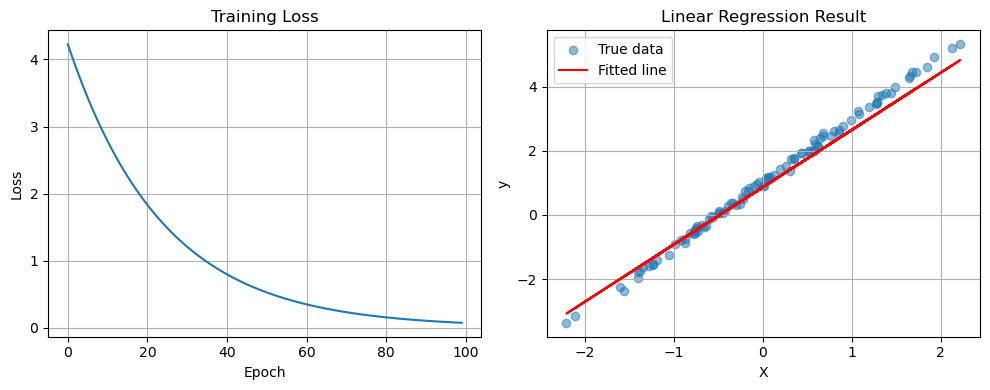

In [121]:
# Plot loss curve
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X.numpy(), y_true.numpy(), alpha=0.5, label='True data')
plt.plot(X.numpy(), y_pred.detach().numpy(), 'r-', label='Fitted line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Result')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Using PyTorch Optimizer

PyTorch provides optimizers that handle gradient updates automatically.

In [122]:
# Reset parameters
w = torch.randn(1, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

# Create optimizer
optimizer = torch.optim.SGD([w, b], lr=0.01)

print(f"Initial: w={w.item():.4f}, b={b.item():.4f}")

for epoch in range(100):
    # Forward
    y_pred = X @ w + b
    loss = ((y_pred - y_true) ** 2).mean()
    
    # Backward
    optimizer.zero_grad()  # Clear gradients
    loss.backward()         # Compute gradients
    optimizer.step()        # Update parameters
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}: Loss={loss.item():.6f}, w={w.item():.4f}, b={b.item():.4f}")

print(f"\nFinal: w={w.item():.4f}, b={b.item():.4f}")

Initial: w=1.2651, b=-0.3178
Epoch  20: Loss=1.078685, w=1.5246, b=0.1332
Epoch  40: Loss=0.468664, w=1.6928, b=0.4302
Epoch  60: Loss=0.206180, w=1.8019, b=0.6257
Epoch  80: Loss=0.093214, w=1.8725, b=0.7545
Epoch 100: Loss=0.044587, w=1.9181, b=0.8394

Final: w=1.9181, b=0.8394


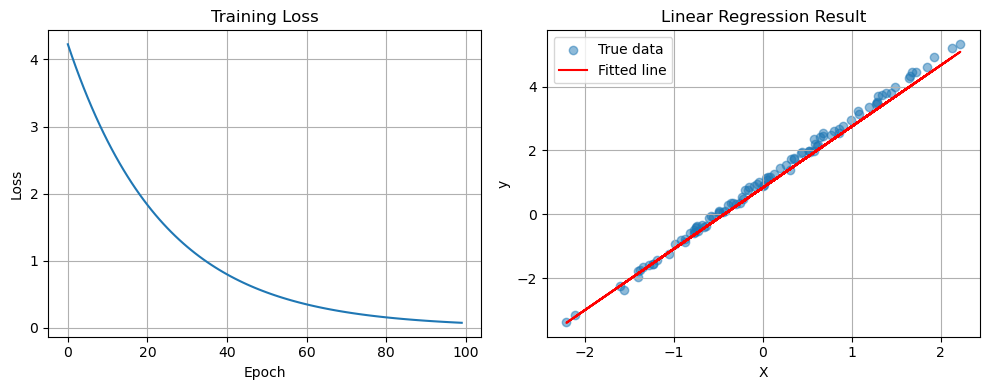

In [123]:
# Plot loss curve
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X.numpy(), y_true.numpy(), alpha=0.5, label='True data')
plt.plot(X.numpy(), y_pred.detach().numpy(), 'r-', label='Fitted line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Result')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

<a id='quick-reference'></a>
## Autograd Cheat Sheet

### Basic Operations
```python
# Enable gradient tracking
x = torch.tensor([1.0], requires_grad=True)

# Forward pass
y = x ** 2

# Backward pass
y.backward()

# Access gradient
print(x.grad)
```

### Gradient Management
```python
# Clear gradients
x.grad.zero_()
optimizer.zero_grad()

# Disable tracking
with torch.no_grad():
    y = x * 2

# Detach from graph
y_detached = y.detach()

# Keep non-leaf gradients
y.retain_grad()
```

### Training Loop
```python
for epoch in range(epochs):
    # Forward
    output = model(input)
    loss = criterion(output, target)
    
    # Backward
    optimizer.zero_grad()  # Clear gradients
    loss.backward()         # Compute gradients
    optimizer.step()        # Update weights
```

### Common Attributes
```python
x.requires_grad     # Is tracking enabled?
x.grad              # Gradient value
x.grad_fn           # Function that created this tensor
x.is_leaf           # Is this a leaf tensor?
```

### Debugging
```python
# Check if gradient is computed
print(x.grad is not None)

# Check for NaN/Inf in gradients
torch.isnan(x.grad).any()
torch.isinf(x.grad).any()

# Print computation graph
print(y.grad_fn)
```